In [1]:
import random
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import matplotlib.pyplot as plot

from torchvision import datasets
from torchvision.models import resnet152, ResNet152_Weights
from torch.utils.data import DataLoader, random_split

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)

if torch.cuda.is_available():
    print("GPU: ", torch.cuda.get_device_name(0))

Device:  cuda
GPU:  Tesla T4


In [9]:
EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 0.0001

NUM_CLASSES = 10

VALIDATION_SIZE = 10000
TRAIN_SIZE = 40000

In [10]:
weights = ResNet152_Weights.DEFAULT

transform = weights.transforms()

DATA_PATH = "/content/drive/MyDrive/ATML/data"

full_dataset = datasets.CIFAR10(
    root = DATA_PATH,
    train = True,
    download = True,
    transform = transform
)

test_dataset = datasets.CIFAR10(
    root = DATA_PATH,
    train = False,
    download = True,
    transform = transform
)

classes = full_dataset.classes

print("Training + Validation images:", len(full_dataset))
print("Test images:", len(test_dataset))
print("Classes:", classes)

Training + Validation images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [11]:
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset = random_split(full_dataset, [TRAIN_SIZE, VALIDATION_SIZE], generator= split_generator)

def create_data_loaders():
    shuffle_generator = torch.Generator().manual_seed(SEED)

    train_loader = DataLoader(train_dataset, batch_size= BATCH_SIZE, shuffle= True, generator= shuffle_generator, num_workers= 2, pin_memory= torch.cuda.is_available())

    validation_loader = DataLoader(validation_dataset, batch_size= BATCH_SIZE, shuffle= False, num_workers= 2, pin_memory= torch.cuda.is_available())

    test_loader = DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle= False, num_workers= 2, pin_memory= torch.cuda.is_available())

    return train_loader, validation_loader, test_loader

In [12]:
train_loader, validation_loader, test_loader = create_data_loaders()

images, labels = next(iter(train_loader))

print("Image batch shape: ", images.shape)
print("Label batch shape: ", labels.shape)

print("Example labels:", labels[:10])

print("Example class names: ", [classes[label] for label in labels[:10]])


Image batch shape:  torch.Size([16, 3, 224, 224])
Label batch shape:  torch.Size([16])
Example labels: tensor([3, 7, 6, 6, 3, 7, 6, 3, 8, 9])
Example class names:  ['cat', 'horse', 'frog', 'frog', 'cat', 'horse', 'frog', 'cat', 'ship', 'truck']


In [13]:
def create_model(initialization, fine_tuning):
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    if initialization == "pretrained":
        model = resnet152(weights = ResNet152_Weights.DEFAULT)

    elif initialization == "random":
        model = resnet152(weights = None)

    else:
        raise ValueError("Initialization must be pretrained or random")

    #! Remove the final classification layer with this
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    #! Fine Tuning
    if fine_tuning == "final_block":
        for parameter in model.parameters():
            parameter.requires_grad = False
        #! Only Layer 4 and classification Layer
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif fine_tuning == "full":
        for parameter in model.parameters():
            parameter.requires_grad = True

    else:
        raise ValueError("Fine Tuning must be either final block or full")

    model = model.to(device)

    return model

In [14]:
#! Counting parameters of the model and how many can be trainable
def count_parameters(model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())

    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

    trainable_percentage = (100 * trainable_parameters/ total_parameters)

    return (total_parameters, trainable_parameters, trainable_percentage)

In [15]:
def set_training_mode(model, fine_tuning):

    model.train()

    if fine_tuning == "final_block":
        model.conv1.eval()
        model.bn1.eval()
        model.relu.eval()
        model.maxpool.eval()

        model.layer1.eval()
        model.layer2.eval()
        model.layer3.eval()

In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, fine_tuning):

    set_training_mode(model, fine_tuning)

    running_loss = 0.0
    correct_prediction = 0
    total_prediction = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none = True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += (loss.item() * images.size(0))

        predictions = outputs.argmax(dim = 1)

        correct_prediction += (predictions == labels).sum().item()

        total_prediction += labels.size(0)

    epoch_loss = (running_loss/ total_prediction)

    epoch_accuracy = (correct_prediction/ total_prediction * 100)

    return epoch_loss, epoch_accuracy

In [17]:
def evaluate(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += (loss.item() *  images.size(0))

            predictions = outputs.argmax(dim = 1)

            correct_predictions += (predictions == labels).sum().item()

            total_predictions += labels.size(0)

        average_loss = (running_loss / total_predictions)

        accuracy = (100 * correct_predictions/total_predictions)

        return average_loss, accuracy

In [18]:
def run_experiment(experiment_name, initialization, fine_tuning):
    print("-" * 60)
    print(experiment_name)
    print("-" * 60)

    train_loader, validation_loader, test_loader = (create_data_loaders())

    model = create_model(initialization, fine_tuning)

    (total_parameters, trainable_parameters, trainable_percentage) = count_parameters(model)

    print("Total parameters: ", total_parameters)
    print("Trainable parameters: ", trainable_parameters)
    print("Trainable percentage: ", trainable_percentage)

    criterion = nn.CrossEntropyLoss()
    #! only update trainable parameters
    optimizer = torch.optim.Adam(filter(lambda parameter: parameter.requires_grad, model.parameters()), lr = LEARNING_RATE)

    history = {
                "training_loss" : [],
                "validation_loss" : [],
                "training_accuracy" : [],
                "validation_accuracy" : [],
              }

    if torch.cuda.is_available():
        torch.cuda.empty_cache() #! clears unused catched GPU memory
        torch.cuda.reset_peak_memory_stats() #! start measuring GPU memory from now
        torch.cuda.synchronize() #! GPU and torch is synchronized

    start_time = time.perf_counter()

    for epoch in range(EPOCHS):
        training_loss, training_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, fine_tuning)

        validation_loss, validation_accuracy = evaluate(model, validation_loader, criterion)

        history["training_loss"].append(training_loss)
        history["training_accuracy"].append(training_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        print(
                f"Epoch {epoch + 1}/{EPOCHS} | "
                f"Train Loss: {training_loss:.4f} | "
                f"Train Acc: {training_accuracy:.2f}% | "
                f"Val Loss: {validation_loss:.4f} | "
                f"Val Acc: {validation_accuracy:.2f}%"
             )

    if torch.cuda.is_available():
            torch.cuda.synchronize()

    end_time = time.perf_counter()

    training_seconds = (end_time - start_time)

    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    if torch.cuda.is_available():
        #! allocate peak memory here
        peak_memory_gb = (torch.cuda.max_memory_allocated() / (1024 ** 3))
    else:
        peak_memory_gb = None

    if peak_memory_gb is not None:
        print("Peak GPU Memory: ", f"{peak_memory_gb:.2f} GB")

    summary = {
                "Experiment": experiment_name,
                "Initialization": initialization,
                "Fine Tuning": fine_tuning,
                "Total Parameters": total_parameters,
                "Trainable Parameters": trainable_parameters,
                "Trainable Percentage": trainable_percentage,
                "Best Validation Accuracy": max(history["validation_accuracy"]),
                "Test Accuracy": test_accuracy,
                "Training Time (Minutes)": (training_seconds / 60),
                "Peak GPU Memory (GB)": peak_memory_gb
                }

    del model
    del optimizer

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, summary


In [19]:
histories = {}
summaries = []

In [20]:
history, summary = run_experiment(
                                    experiment_name= "Pretrained - Final Block",
                                    initialization= "pretrained",
                                    fine_tuning= "final_block"
                                 )

histories["Pretrained - Final Block"] = history
summaries.append(summary)

------------------------------------------------------------
Pretrained - Final Block
------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 171MB/s]


Total parameters:  58164298
Trainable parameters:  14985226
Trainable percentage:  25.763615336679557
Epoch 1/5 | Train Loss: 0.2401 | Train Acc: 92.61% | Val Loss: 0.1254 | Val Acc: 95.89%
Epoch 2/5 | Train Loss: 0.0680 | Train Acc: 97.77% | Val Loss: 0.1238 | Val Acc: 96.07%
Epoch 3/5 | Train Loss: 0.0301 | Train Acc: 99.08% | Val Loss: 0.1388 | Val Acc: 96.06%
Epoch 4/5 | Train Loss: 0.0198 | Train Acc: 99.35% | Val Loss: 0.1511 | Val Acc: 96.04%
Epoch 5/5 | Train Loss: 0.0150 | Train Acc: 99.51% | Val Loss: 0.1527 | Val Acc: 95.99%
Peak GPU Memory:  0.57 GB


In [21]:
history, summary = run_experiment(
                                    experiment_name= "Pretrained - Full",
                                    initialization= "pretrained",
                                    fine_tuning= "full"
                                 )

histories["Pretrained - Full"] = history
summaries.append(summary)

------------------------------------------------------------
Pretrained - Full
------------------------------------------------------------
Total parameters:  58164298
Trainable parameters:  58164298
Trainable percentage:  100.0
Epoch 1/5 | Train Loss: 0.2946 | Train Acc: 90.47% | Val Loss: 0.1476 | Val Acc: 94.95%
Epoch 2/5 | Train Loss: 0.1171 | Train Acc: 96.10% | Val Loss: 0.1416 | Val Acc: 95.28%
Epoch 3/5 | Train Loss: 0.0772 | Train Acc: 97.43% | Val Loss: 0.1294 | Val Acc: 95.57%
Epoch 4/5 | Train Loss: 0.0654 | Train Acc: 97.87% | Val Loss: 0.1366 | Val Acc: 95.65%
Epoch 5/5 | Train Loss: 0.0511 | Train Acc: 98.30% | Val Loss: 0.1516 | Val Acc: 95.56%
Peak GPU Memory:  3.43 GB


In [22]:
history, summary = run_experiment(
                                    experiment_name= "Random - Final Block",
                                    initialization= "random",
                                    fine_tuning= "final_block"
                                 )

histories["Random - Final Block"] = history
summaries.append(summary)

------------------------------------------------------------
Random - Final Block
------------------------------------------------------------
Total parameters:  58164298
Trainable parameters:  14985226
Trainable percentage:  25.763615336679557
Epoch 1/5 | Train Loss: 2.2149 | Train Acc: 18.33% | Val Loss: 2.1602 | Val Acc: 20.94%
Epoch 2/5 | Train Loss: 2.0957 | Train Acc: 22.77% | Val Loss: 2.0645 | Val Acc: 22.91%
Epoch 3/5 | Train Loss: 2.0265 | Train Acc: 25.75% | Val Loss: 2.0375 | Val Acc: 24.34%
Epoch 4/5 | Train Loss: 1.9761 | Train Acc: 27.94% | Val Loss: 1.9523 | Val Acc: 27.66%
Epoch 5/5 | Train Loss: 1.9431 | Train Acc: 29.15% | Val Loss: 1.9865 | Val Acc: 27.79%
Peak GPU Memory:  0.57 GB


In [23]:
history, summary = run_experiment(
                                    experiment_name= "Random - Full",
                                    initialization= "random",
                                    fine_tuning= "full"
                                 )

histories["Random - Full"] = history
summaries.append(summary)

------------------------------------------------------------
Random - Full
------------------------------------------------------------
Total parameters:  58164298
Trainable parameters:  58164298
Trainable percentage:  100.0
Epoch 1/5 | Train Loss: 1.8655 | Train Acc: 31.30% | Val Loss: 1.6178 | Val Acc: 43.17%
Epoch 2/5 | Train Loss: 1.4797 | Train Acc: 46.38% | Val Loss: 1.4040 | Val Acc: 52.36%
Epoch 3/5 | Train Loss: 1.2419 | Train Acc: 55.39% | Val Loss: 1.1479 | Val Acc: 59.67%
Epoch 4/5 | Train Loss: 1.0016 | Train Acc: 64.87% | Val Loss: 1.0008 | Val Acc: 67.68%
Epoch 5/5 | Train Loss: 0.8040 | Train Acc: 71.92% | Val Loss: 1.0229 | Val Acc: 70.19%
Peak GPU Memory:  3.43 GB


In [24]:
results = pd.DataFrame(summaries)

results

,Experiment,Initialization,Fine Tuning,Total Parameters,Trainable Parameters,Trainable Percentage,Best Validation Accuracy,Test Accuracy,Training Time (Minutes),Peak GPU Memory (GB)
0,Pretrained - Final Block,pretrained,final_block,58164298,14985226,25.763615,96.07,95.94,35.561098,0.569066
1,Pretrained - Full,pretrained,full,58164298,58164298,100.000000,95.65,95.59,87.234412,3.428010
2,Random - Final Block,random,final_block,58164298,14985226,25.763615,27.79,28.03,35.737051,0.570378
3,Random - Full,random,full,58164298,58164298,100.000000,70.19,70.02,88.831510,3.428010


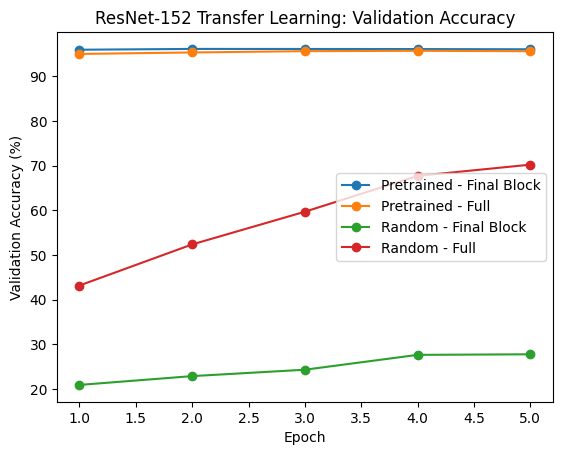

In [25]:
epochs = range(1, EPOCHS + 1)

for experiment_name, history in histories.items():

    plot.plot(epochs, history["validation_accuracy"], marker = "o", label = experiment_name)

plot.xlabel("Epoch")
plot.ylabel("Validation Accuracy (%)")
plot.title("ResNet-152 Transfer Learning: Validation Accuracy")
plot.legend()

plot.show()

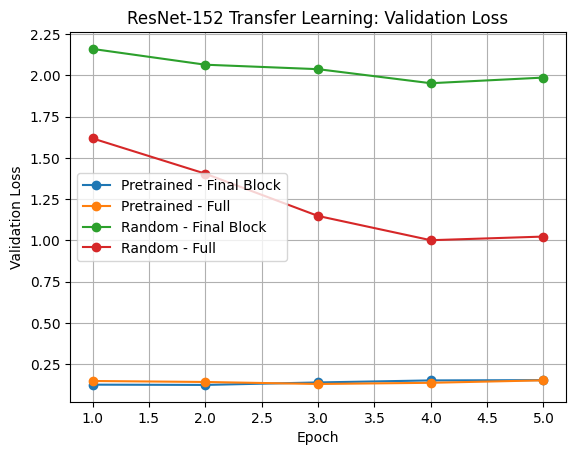

In [26]:
for experiment_name, history in histories.items():

    plot.plot(epochs, history["validation_loss"], marker = "o", label = experiment_name)

plot.xlabel("Epoch")
plot.ylabel("Validation Loss")
plot.title("ResNet-152 Transfer Learning: Validation Loss")
plot.legend()
plot.grid()

plot.show()

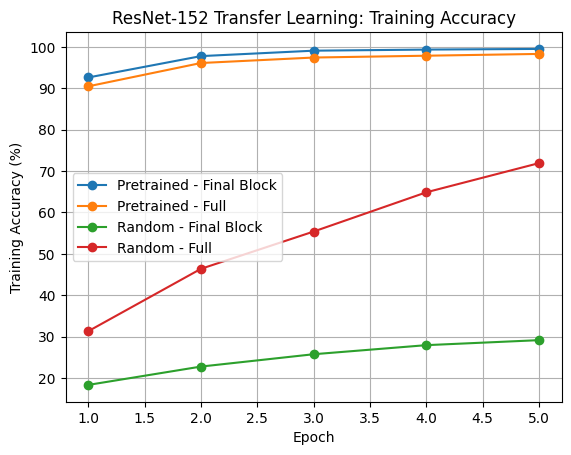

In [27]:
for experiment_name, history in histories.items():

    plot.plot(epochs, history["training_accuracy"], marker = "o", label = experiment_name)

plot.xlabel("Epoch")
plot.ylabel("Training Accuracy (%)")
plot.title("ResNet-152 Transfer Learning: Training Accuracy")
plot.legend()
plot.grid()

plot.show()

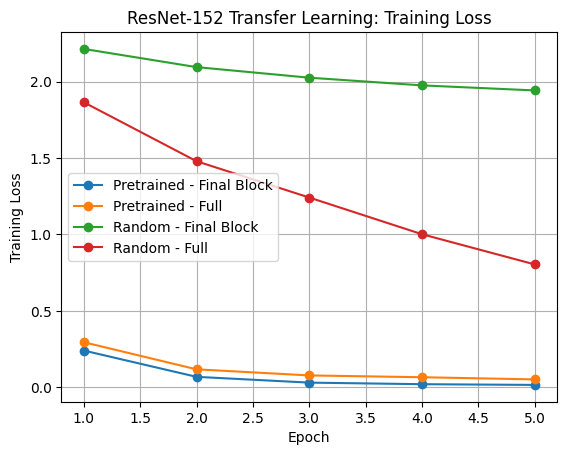

In [28]:
for experiment_name, history in histories.items():

    plot.plot(epochs, history["training_loss"], marker = "o", label = experiment_name)

plot.xlabel("Epoch")
plot.ylabel("Training Loss")
plot.title("ResNet-152 Transfer Learning: Training Loss")
plot.legend()
plot.grid()

plot.show()

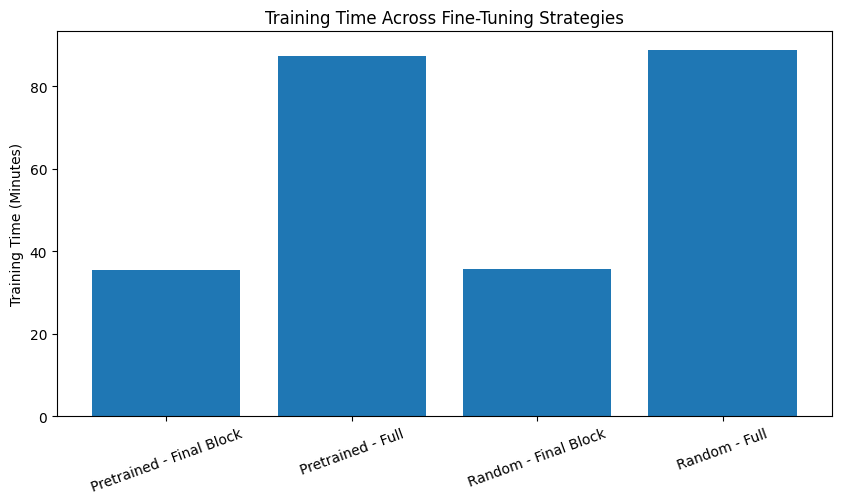

In [29]:
plot.figure(figsize = (10, 5))

plot.bar(results["Experiment"], results["Training Time (Minutes)"])

plot.ylabel("Training Time (Minutes)")
plot.title("Training Time Across Fine-Tuning Strategies")
plot.xticks(rotation = 20)

plot.show()

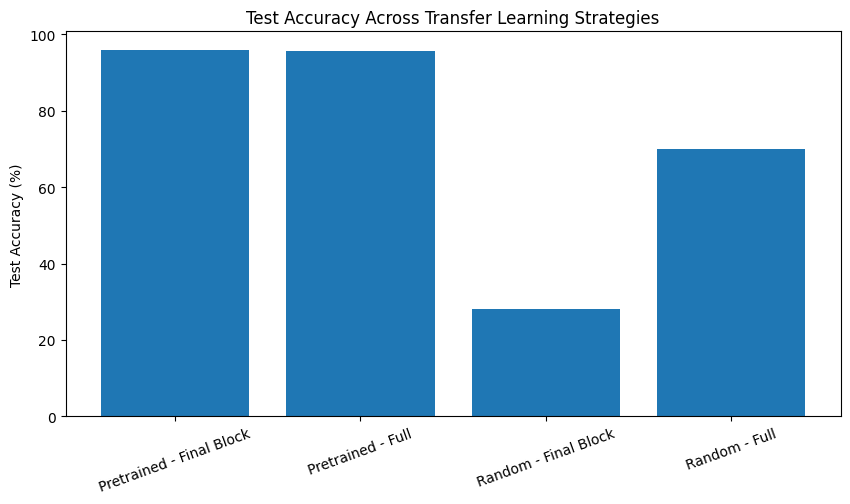

In [30]:
plot.figure(figsize = (10, 5))

plot.bar(results["Experiment"], results["Test Accuracy"])

plot.ylabel("Test Accuracy (%)")
plot.title("Test Accuracy Across Transfer Learning Strategies")
plot.xticks(rotation = 20)

plot.show()

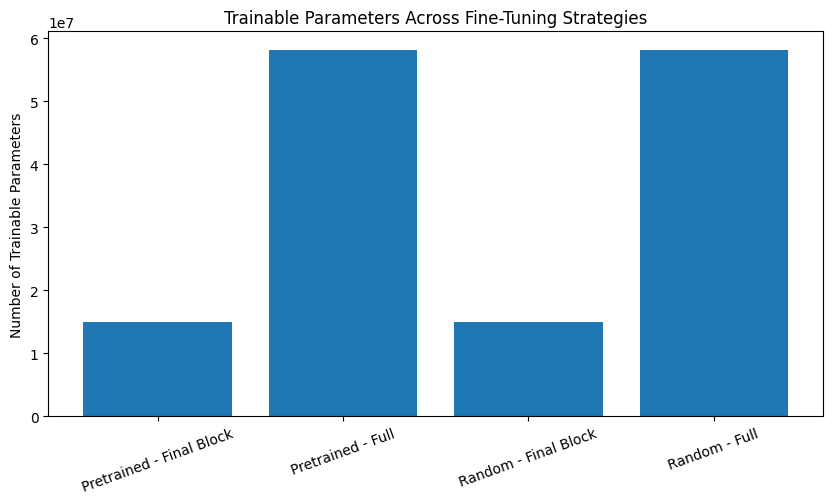

In [31]:
plot.figure(figsize = (10, 5))

plot.bar(results["Experiment"], results["Trainable Parameters"])

plot.ylabel("Number of Trainable Parameters")
plot.title("Trainable Parameters Across Fine-Tuning Strategies")
plot.xticks(rotation = 20)

plot.show()

In [32]:
best_accuracy_index = (results["Test Accuracy"].idxmax())

best_accuracy_model = (results.loc[best_accuracy_index])

fastest_index = (results["Training Time (Minutes)"].idxmin())

fastest_model = (results.loc[fastest_index])

print("Highest Test Accuracy")
print("---------------------")

print(best_accuracy_model["Experiment"])
print(f"Accuracy: " f"{best_accuracy_model['Test Accuracy']:.2f}%")
print()
print("Fastest Training")
print("----------------")
print(fastest_model["Experiment"])
print(f"Time: "f"{fastest_model['Training Time (Minutes)']:.2f} minutes")

Highest Test Accuracy
---------------------
Pretrained - Final Block
Accuracy: 95.94%

Fastest Training
----------------
Pretrained - Final Block
Time: 35.56 minutes
